# Business Understanding

Industri pengolahan susu membutuhkan proses kontrol kualitas yang cepat, akurat, dan efisien untuk memastikan setiap produk memenuhi standar keamanan dan mutu. Penilaian kualitas secara manual dapat memakan waktu dan rentan terhadap kesalahan subjektif. Oleh karena itu, diperlukan sistem cerdas berbasis data untuk memprediksi kualitas susu secara otomatis.



## Project Domain

Proyek ini berada dalam domain Food Quality Control dan Machine Learning (Classification), khususnya penerapan Artificial Neural Network (ANN) untuk klasifikasi kualitas produk pangan (dalam hal ini, susu).

## Problem Statements

Bagaimana membangun model prediktif berbasis ANN yang mampu:

Menganalisis dan memahami kontribusi parameter fisik dan kimia susu (seperti pH, temperatur, rasa, bau, lemak, kekeruhan, dan warna) terhadap kualitas akhir produk?

Mengklasifikasikan kualitas susu secara otomatis ke dalam tiga kategori: Low, Medium, dan High?

## Goals

Mengembangkan model klasifikasi yang akurat untuk memprediksi grade (kualitas) susu.

Mengurangi ketergantungan pada proses manual dalam kontrol kualitas.

Memberikan insight kepada produsen mengenai faktor-faktor utama yang memengaruhi mutu susu.

## Solution Statements

Melakukan preprocessing data, termasuk normalisasi dan encoding variabel.

Menggunakan Artificial Neural Network (ANN) untuk membangun model klasifikasi dengan kemampuan generalisasi yang tinggi.

Mengevaluasi model dengan metrik seperti akurasi, confusion matrix, dan classification report.

Menyediakan sistem yang dapat diintegrasikan ke dalam proses produksi untuk prediksi kualitas real-time.

# Data Understanding

## Import data dari kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dimasss12345","key":"fe0fd409ffdc487c05cb2bd0781339d0"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [4]:
!kaggle datasets download -d cpluzshrijayan/milkquality

Dataset URL: https://www.kaggle.com/datasets/cpluzshrijayan/milkquality
License(s): unknown


In [5]:
!mkdir milkquality
!unzip milkquality.zip -d milkquality
!ls milkquality

Archive:  milkquality.zip
  inflating: milkquality/milknew.csv  
milknew.csv


## Import Library yang dibutuhkan

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

## Exploratory Data Analysis

In [7]:
milk_data = pd.read_csv('/content/milkquality/milknew.csv')

In [8]:
milk_data.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium


In [9]:
milk_data.head(), milk_data.isnull().sum()

(    pH  Temprature  Taste  Odor  Fat   Turbidity  Colour   Grade
 0  6.6          35      1     0     1          0     254    high
 1  6.6          36      0     1     0          1     253    high
 2  8.5          70      1     1     1          1     246     low
 3  9.5          34      1     1     0          1     255     low
 4  6.6          37      0     0     0          0     255  medium,
 pH            0
 Temprature    0
 Taste         0
 Odor          0
 Fat           0
 Turbidity     0
 Colour        0
 Grade         0
 dtype: int64)

In [10]:
# 1. Descriptive Statistics
print(milk_data.describe())

                pH   Temprature        Taste         Odor         Fat   \
count  1059.000000  1059.000000  1059.000000  1059.000000  1059.000000   
mean      6.630123    44.226629     0.546742     0.432483     0.671388   
std       1.399679    10.098364     0.498046     0.495655     0.469930   
min       3.000000    34.000000     0.000000     0.000000     0.000000   
25%       6.500000    38.000000     0.000000     0.000000     0.000000   
50%       6.700000    41.000000     1.000000     0.000000     1.000000   
75%       6.800000    45.000000     1.000000     1.000000     1.000000   
max       9.500000    90.000000     1.000000     1.000000     1.000000   

         Turbidity       Colour  
count  1059.000000  1059.000000  
mean      0.491029   251.840415  
std       0.500156     4.307424  
min       0.000000   240.000000  
25%       0.000000   250.000000  
50%       0.000000   255.000000  
75%       1.000000   255.000000  
max       1.000000   255.000000  


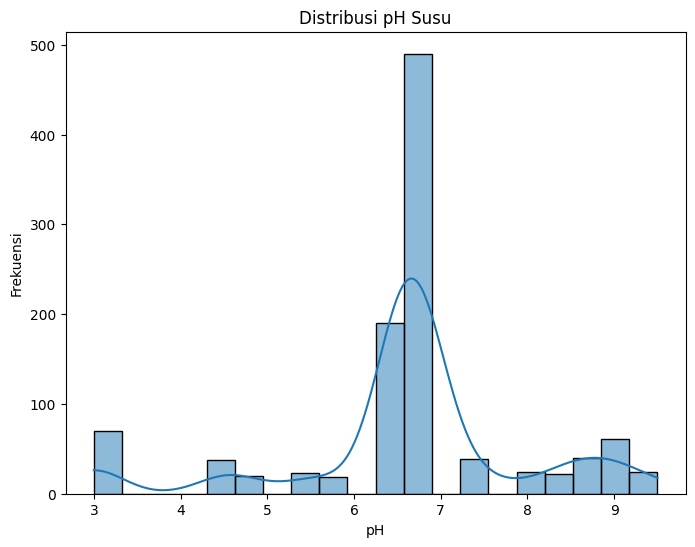

In [11]:
# 2. Distribusi 'pH'
plt.figure(figsize=(8, 6))
sns.histplot(milk_data['pH'], kde=True, bins=20)
plt.title('Distribusi pH Susu')
plt.xlabel('pH')
plt.ylabel('Frekuensi')
plt.show()

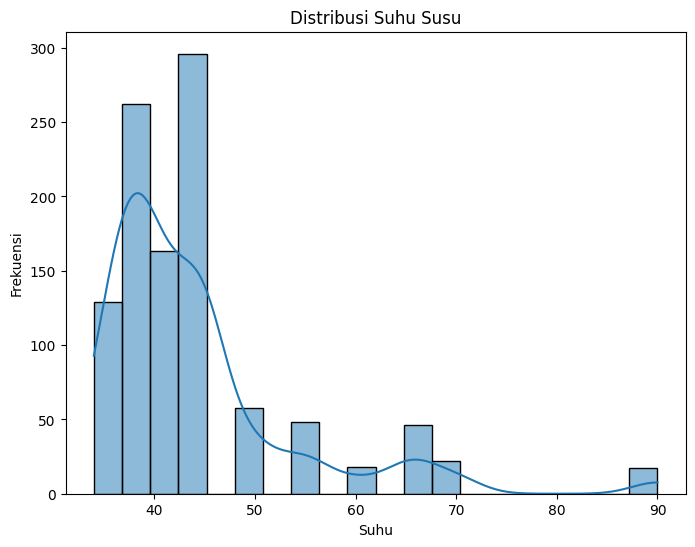

In [12]:
# 3. Distribusi 'Temperature'
plt.figure(figsize=(8, 6))
sns.histplot(milk_data['Temprature'], kde=True, bins=20)
plt.title('Distribusi Suhu Susu')
plt.xlabel('Suhu')
plt.ylabel('Frekuensi')
plt.show()

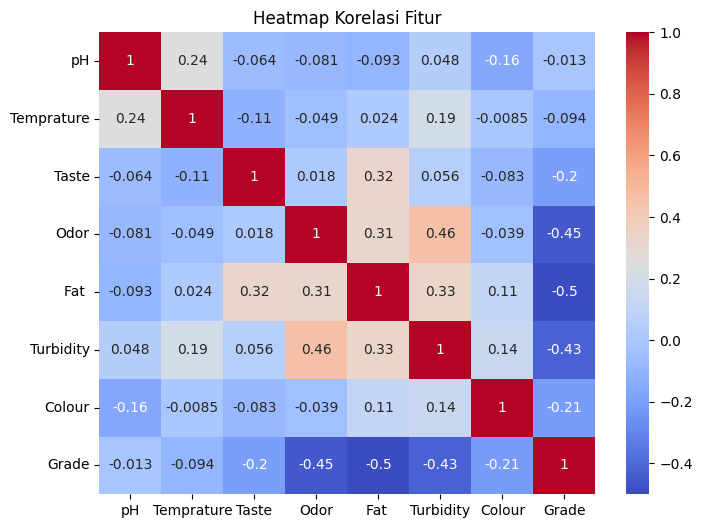

In [16]:
# 4. Korelasi antara fitur-fitur numerik
plt.figure(figsize=(8, 6))
sns.heatmap(milk_data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')
plt.show()

In [14]:
# 5. Distribusi 'Grade' (Target)
print(milk_data['Grade'].value_counts())

Grade
low       429
medium    374
high      256
Name: count, dtype: int64


# Data Preparation

In [15]:
label_encoder = LabelEncoder()
milk_data['Grade'] = label_encoder.fit_transform(milk_data['Grade'])

In [17]:
X = milk_data[['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour']]
y = milk_data['Grade']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((847, 7), (212, 7), (847,), (212,))

# Modeling

In [21]:
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,459 (44.76 KB)

 Trainable params: 11,459 (44.76 KB)

 Non-trainable params: 0 (0.00 B)

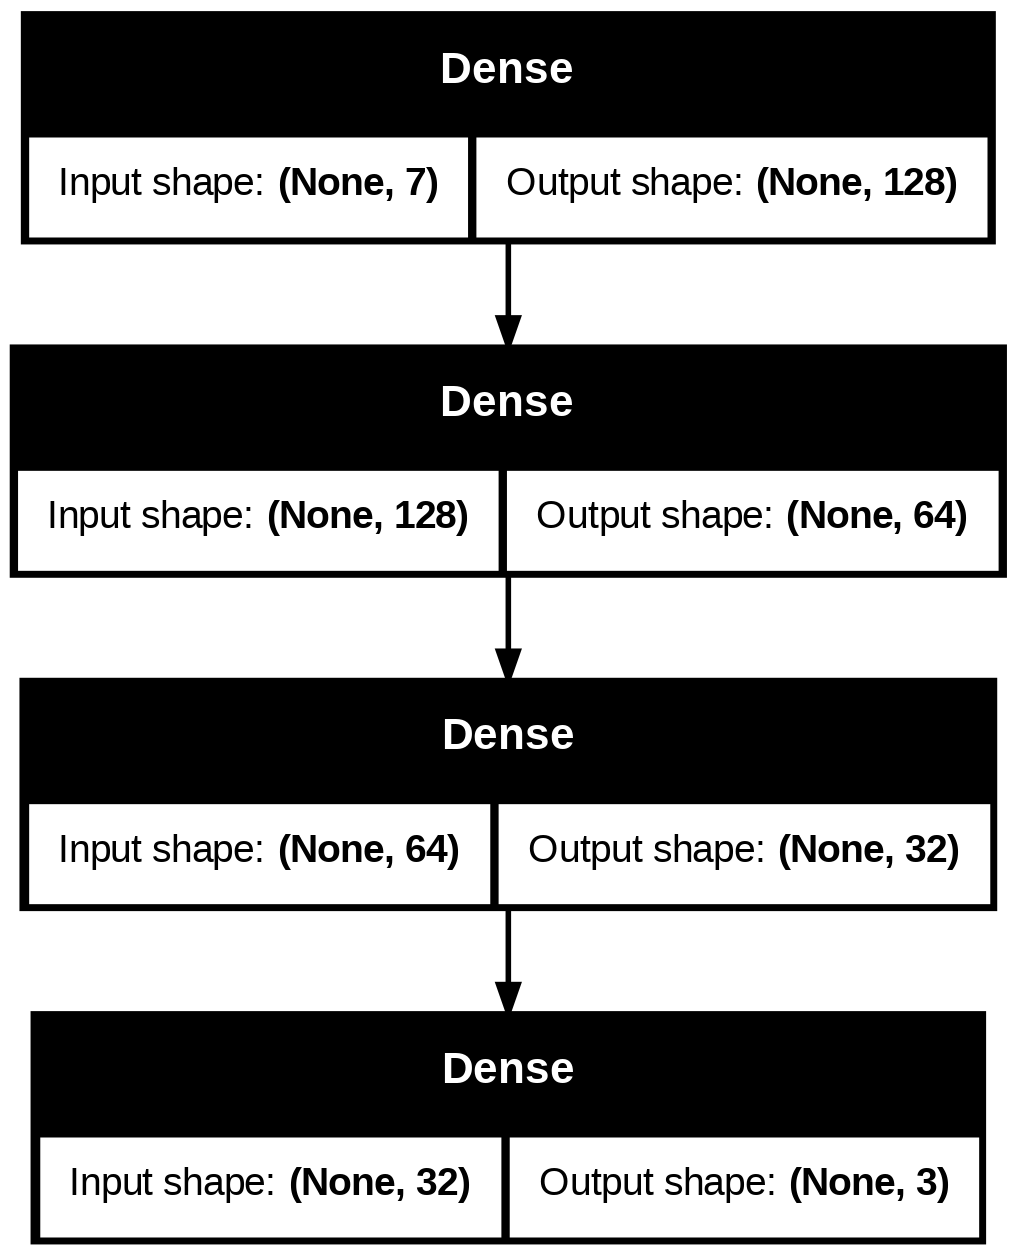

In [25]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [26]:
history_injury = model.fit(X_train, y_train,
                           epochs=50,
                           batch_size=32,
                           validation_data=(X_test, y_test))

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9953 - val_loss: 0.0124
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9953 - val_loss: 0.0123
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 8.7038e-04 - val_accuracy: 0.9953 - val_loss: 0.0123
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 8.6991e-04 - val_accuracy: 0.9953 - val_loss: 0.0122
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 7.6504e-04 - val_accuracy: 0.9953 - val_loss: 0.0128
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.7804e-04 - val_accuracy: 0.9953 - val_loss: 0.0124
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.6566e-04 - val_accuracy: 0.9953 - val_loss: 0.0124
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.9765e-04 - val_acc

# Evaluation

In [27]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Loss (MSE): {loss}")
print(f"Model Accuracy: {accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9893 - loss: 0.0297 
Model Loss (MSE): 0.013169871643185616
Model Accuracy: 0.9952830076217651


In [28]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

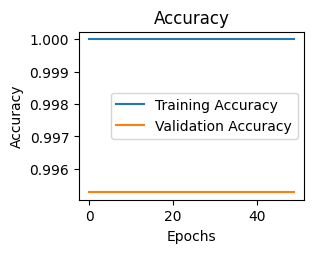

In [33]:
plt.subplot(2, 2, 4)
plt.plot(history_injury.history["accuracy"], label='Training Accuracy')
plt.plot(history_injury.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

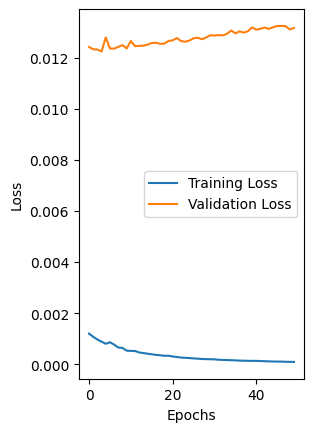

In [34]:
plt.subplot(1, 2, 2)
plt.plot(history_injury.history["loss"], label='Training Loss')
plt.plot(history_injury.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Deployment

## Model Simulation

In [36]:
new_milk = [[6.6, 37, 0, 0, 0, 0, 255]]  # [pH, Temperatur, Taste, Odor, Fat, Turbidity, Colour]

new_milk_scaled = scaler.transform(new_milk)

predicted_grade = model.predict(new_milk_scaled)
predicted_grade_label = label_encoder.inverse_transform([predicted_grade.argmax()])
print(f"Prediksi Kualitas Susu: {predicted_grade_label[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediksi Kualitas Susu: medium


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
predictions = model.predict(X_test)

for i in range(5):
    print(f"Prediksi: {label_encoder.inverse_transform([predictions[i].argmax()])[0]}, Nilai Sebenarnya: {label_encoder.inverse_transform([y_test.iloc[i]])[0]}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Prediksi: high, Nilai Sebenarnya: high
Prediksi: low, Nilai Sebenarnya: low
Prediksi: low, Nilai Sebenarnya: low
Prediksi: medium, Nilai Sebenarnya: medium
Prediksi: medium, Nilai Sebenarnya: medium


## Save Model

In [38]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('milkquality.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp396lg_cm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137639685646352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685647504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685645776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685643856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685648080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685644240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685648464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137639685647312: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [39]:
import joblib
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']